In [1]:
import pandas as pd
import numpy as np

df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_sites_qc_btm = df_sites_qc.iloc[[x=='BTM' for x in site_depth],:]
df_sites_qc_btm = df_sites_qc_btm.loc[:,df_sites_qc_btm.sum()>0]


In [2]:
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v3.csv', index_col = 0,encoding='latin-1')
#df_env.columns = [x[0:10] for x in df_env.columns]

df_env = df_env.iloc[:,np.append(range(0,28), range(56,61))]
df_env = df_env.drop(['TKN_pct'], axis=1)

df_env_top = df_env.loc[df_sites_qc_top.index.values,:]
df_env_btm = df_env.loc[df_sites_qc_btm.index.values,:]

df_env_top_pred = df_env_top.iloc[:,np.append(range(0,21), range(24,32))]
df_env_top_pred = df_env_top_pred.fillna(0.)
df_env_btm_pred = df_env_btm.iloc[:,np.append(range(0,21), range(24,32))]
df_env_btm_pred = df_env_btm.fillna(0.)

In [3]:
df_env_biome = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_meta_v3.csv', index_col = 0,encoding='latin-1')
df_env_biome_top = df_env_biome.loc[df_sites_qc_top.index.values,['biome_name','Respiration_24_h_ug_CO2.C_per_g_soil_per_day']]
df_env_biome_btm = df_env_biome.loc[df_sites_qc_btm.index.values,['biome_name','Respiration_24_h_ug_CO2.C_per_g_soil_per_day']]

In [9]:
df_env_biome_top['NMFs'] = [f"NMF{str(i)}" for i in  nmf_grp7.astype(int)+1]
df_env_biome_btm['NMFs'] = [f"NMF{str(i)}" for i in  nmf_grp5.astype(int)+1]

In [53]:
df_env_biome_top[df_env_biome_top['NMFs']=='NMF5']

,biome_name,Respiration_24_h_ug_CO2.C_per_g_soil_per_day,NMFs
Sample,,,
FTA3_TOP,Deserts & Xeric Shrublands,48.6726,NMF5
ISNC_TOP,"Temperate Grasslands, Savannas & Shrublands",116.9000,NMF5
KONA_TOP,"Temperate Grasslands, Savannas & Shrublands",80.9000,NMF5
MOAB_TOP,Deserts & Xeric Shrublands,13.0000,NMF5
NWBA_TOP,Temperate Broadleaf & Mixed Forests,117.1200,NMF5
OSBS_TOP,Temperate Conifer Forests,15.2000,NMF5
SRER_TOP,Deserts & Xeric Shrublands,24.0000,NMF5
SRR1_TOP,Deserts & Xeric Shrublands,47.8000,NMF5
UT32_TOP,Deserts & Xeric Shrublands,34.8000,NMF5


In [70]:
df_env_biome_btm[df_env_biome_btm['NMFs']=='NMF3']

,biome_name,Respiration_24_h_ug_CO2.C_per_g_soil_per_day,NMFs
Sample,,,
ISCC_BTM,"Temperate Grasslands, Savannas & Shrublands",43.40,NMF3
ISNC_BTM,"Temperate Grasslands, Savannas & Shrublands",46.30,NMF3
MOAB_BTM,Deserts & Xeric Shrublands,11.00,NMF3
OAES_BTM,"Temperate Grasslands, Savannas & Shrublands",20.20,NMF3
OCTU_BTM,Deserts & Xeric Shrublands,15.54,NMF3


In [33]:
df_env_biome_btm = df_env_biome_btm[df_env_biome_btm['biome_name']!='Mediterranean Forests, Woodlands & Scrub']
df_env_biome_top = df_env_biome_top[df_env_biome_top['biome_name']!='Mediterranean Forests, Woodlands & Scrub']

<AxesSubplot:xlabel='Respiration_24_h_ug_CO2.C_per_g_soil_per_day', ylabel='biome_name'>

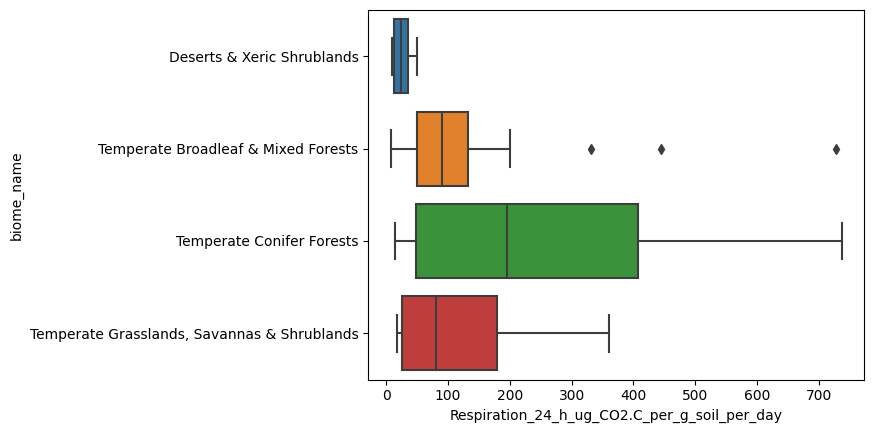

In [13]:
import seaborn as sns
sns.boxplot(data=df_env_biome_top, x='Respiration_24_h_ug_CO2.C_per_g_soil_per_day', y='biome_name', orient="h")

[Text(0, 0, 'Deserts & Xeric Shrublands'),
 Text(1, 0, 'Temperate Broadleaf & Mixed Forests'),
 Text(2, 0, 'Temperate Conifer Forests'),
 Text(3, 0, 'Temperate Grasslands, Savannas & Shrublands')]

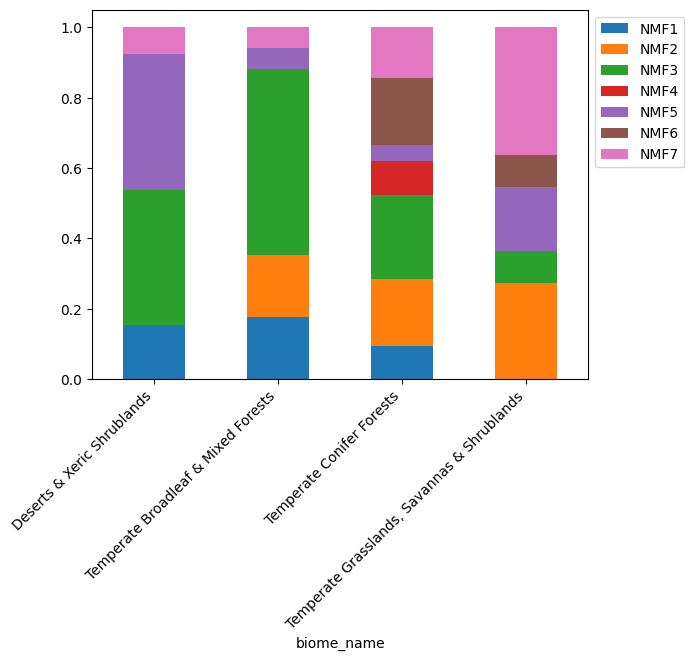

In [14]:
df_nmf_biome_top = df_env_biome_top.groupby(['biome_name', 'NMFs']).size().reset_index().pivot(index='biome_name', columns='NMFs', values=0)
df_nmf_biome_top = df_nmf_biome_top.fillna(0.).transpose()
df_nmf_biome_top = df_nmf_biome_top/df_nmf_biome_top.sum()
axes = df_nmf_biome_top.transpose().plot(kind='bar', stacked=True)
axes.legend(bbox_to_anchor= (1, 1)) 
axes.set_xticklabels(axes.get_xticklabels(), rotation=45, ha='right')
#df_nmf_biome_top

[Text(0, 0, 'Deserts & Xeric Shrublands'),
 Text(1, 0, 'Temperate Broadleaf & Mixed Forests'),
 Text(2, 0, 'Temperate Conifer Forests'),
 Text(3, 0, 'Temperate Grasslands, Savannas & Shrublands')]

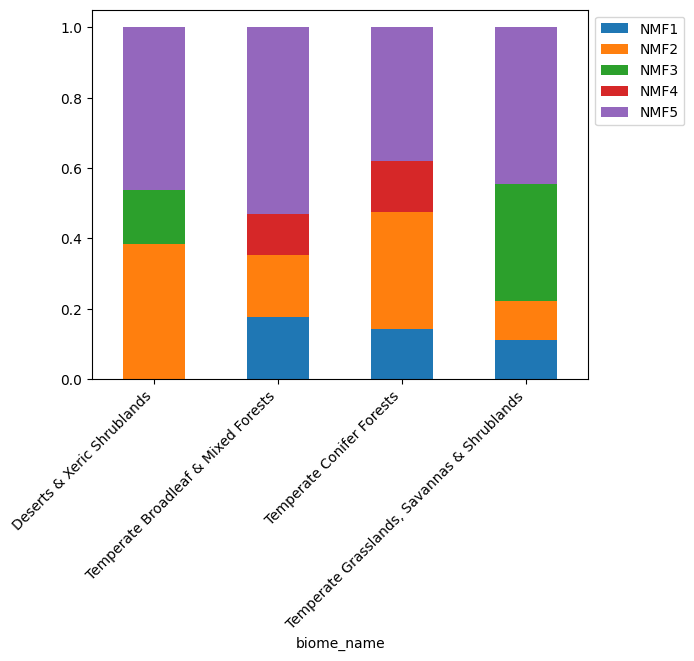

In [15]:
df_nmf_biome_btm = df_env_biome_btm.groupby(['biome_name', 'NMFs']).size().reset_index().pivot(index='biome_name', columns='NMFs', values=0)
df_nmf_biome_btm = df_nmf_biome_btm.fillna(0.).transpose()
df_nmf_biome_btm = df_nmf_biome_btm/df_nmf_biome_btm.sum()
axes = df_nmf_biome_btm.transpose().plot(kind='bar', stacked=True)
axes.legend(bbox_to_anchor= (1, 1)) 
axes.set_xticklabels(axes.get_xticklabels(), rotation=45, ha='right')
#df_nmf_biome_top

In [13]:
biomes = ['Deserts & Xeric Shrublands',
       'Temperate Broadleaf & Mixed Forests', 'Temperate Conifer Forests',
       'Temperate Grasslands, Savannas & Shrublands']
df_env_biome_top[df_env_biome_top['biome_name']==biomes[3]].shape

(11, 3)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


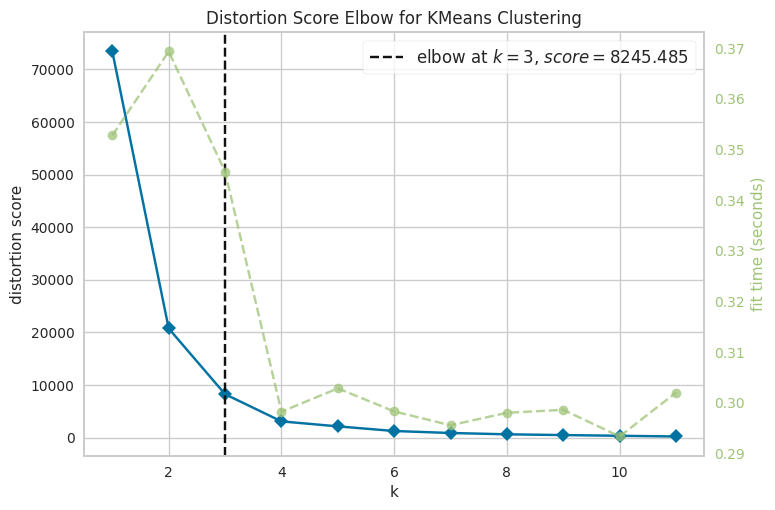

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [14]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
model = KMeans()
visualizer = KElbowVisualizer(model, k=(1,12)).fit(df_env_btm['Respiration_24_h_ug_CO2.C_per_g_soil_per_day'].values.reshape(-1,1))
visualizer.show()

In [10]:
from sklearn.cluster import KMeans
y = df_env_top['Respiration_24_h_ug_CO2.C_per_g_soil_per_day'].values
k_model = KMeans(3).fit(y.reshape(-1,1))
print(k_model.labels_)

[0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 0 0 2 0 0 0 2 0 2 0 0 0 0 0 0
 0 1 2 0 2 0 0 0 0 0 2 1 2 1 1 0 0 0 0 0 0 2 1 2 2 2]


In [11]:
df_env_top['Kmeans'] = k_model.labels_

<AxesSubplot:title={'center':'Respiration_24_h_ug_CO2.C_per_g_soil_per_day'}, xlabel='Kmeans'>

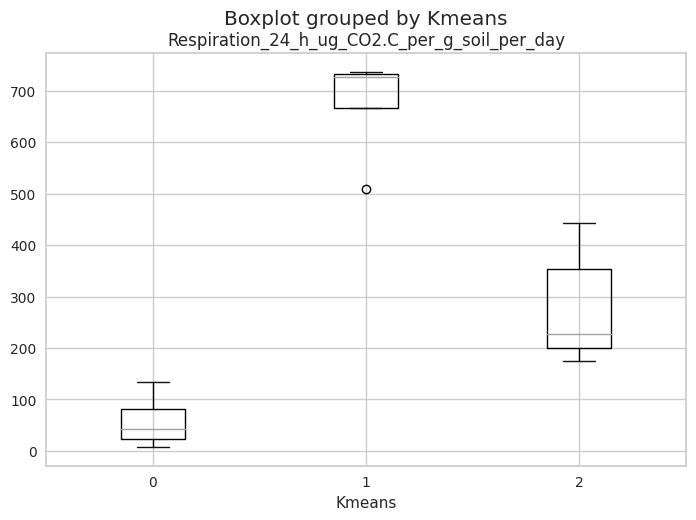

In [26]:
df_env_top.boxplot(column=['Respiration_24_h_ug_CO2.C_per_g_soil_per_day'],by='Kmeans')

In [30]:
df_env_biome_top[df_env_top['Kmeans'] ==1]

/home/shic892/miniconda3/envs/jupyter_plot/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


,biome_name,Respiration_24_h_ug_CO2.C_per_g_soil_per_day,NMFs
Sample,,,
SCBI_TOP,Temperate Broadleaf & Mixed Forests,727.1,NMF3
UT12_TOP,Temperate Conifer Forests,508.8,NMF1
UT23_TOP,Temperate Conifer Forests,736.5,NMF6
UT24_TOP,Temperate Conifer Forests,733.2,NMF6
WY03_TOP,Temperate Conifer Forests,667.0,NMF7


<AxesSubplot:title={'center':'Respiration_24_h_ug_CO2.C_per_g_soil_per_day'}, xlabel='Kmeans'>

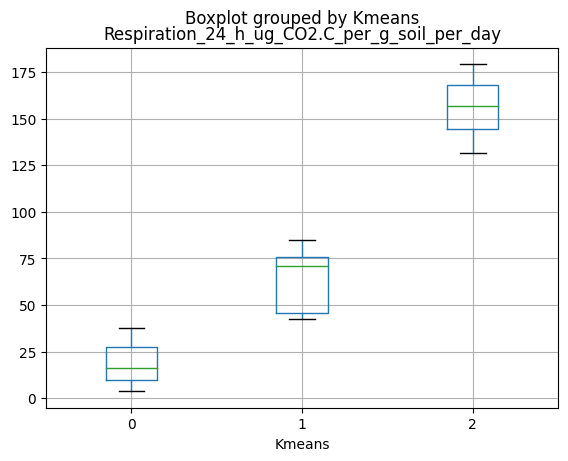

In [50]:
y = df_env_btm['Respiration_24_h_ug_CO2.C_per_g_soil_per_day'].values
k_model = KMeans(3).fit(y.reshape(-1,1))
df_env_btm['Kmeans'] = k_model.labels_
df_env_btm.boxplot(column=['Respiration_24_h_ug_CO2.C_per_g_soil_per_day'],by='Kmeans')


In [7]:
nmf_grp7 = np.array([])
for i in range(datah7.shape[1]):
    nmf_grp7 = np.append(nmf_grp7, np.argmax(datah7[:,i]))
nmf_grp7

array([0., 0., 2., 2., 6., 6., 6., 2., 0., 4., 6., 1., 6., 4., 1., 2., 4.,
       2., 2., 2., 4., 5., 4., 0., 6., 1., 0., 2., 2., 2., 0., 4., 2., 1.,
       2., 2., 2., 6., 2., 1., 1., 2., 4., 4., 1., 2., 1., 1., 0., 1., 5.,
       5., 4., 2., 2., 2., 3., 3., 5., 6., 5., 6., 1.])

array([0., 1., 2., 3., 4., 5., 6.])

In [49]:
for i in np.unique(nmf_grp7):
    print(i)
    print(len(nmf_grp7[nmf_grp7==i]))

0.0
7
1.0
11
2.0
20
3.0
2
4.0
9
5.0
5
6.0
9


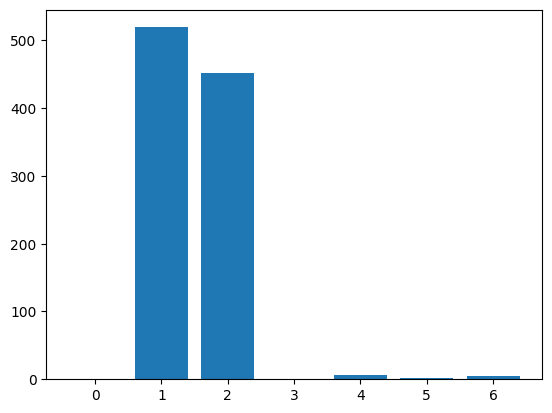

In [28]:
import matplotlib.pyplot as plt
plt.bar(range(0,7),datah7[:,11])
plt.show()

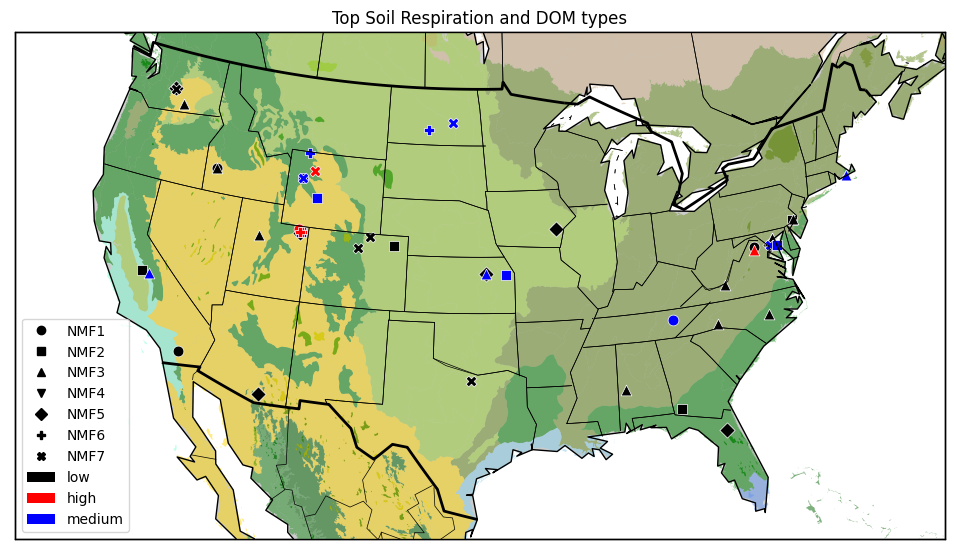

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import matplotlib.patches


fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=5500000,height=3000000,resolution='c',projection='aea',lon_0=-97,lat_0=38.5)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()

m.readshapefile('/home/shic892/pyDNMFk/examples/terr_biomes_ecoregions/wwf_terr_ecos', 'wwf_terr_ecos', drawbounds = False,default_encoding='iso-8859-15')
for info, shape in zip(m.wwf_terr_ecos_info, m.wwf_terr_ecos):
    if info['BIOME'] == 2.0:
        plt.fill(*zip(*shape), 'forestgreen', linewidth=0.1,alpha=0.5) #"Tropical & Subtropical Coniferous Forests"
    if info['BIOME'] == 3.0:
        plt.fill(*zip(*shape), 'darkgreen', linewidth=0.1,alpha=0.5) #"Tropical & Subtropical Coniferous Forests"
    if info['BIOME'] == 4.0:
        plt.fill(*zip(*shape), 'olivedrab', linewidth=0.1,alpha=0.5) #"Temperate Broadleaf & Mixed Forests"
    if info['BIOME'] == 5.0:
        plt.fill(*zip(*shape), 'green', linewidth=0.1,alpha=0.5) #"Temperate Conifer Forests"
    if info['BIOME'] == 6.0:
        plt.fill(*zip(*shape), 'tan', linewidth=0.1,alpha=0.5) #"Boreal Forests/Taiga"    
    if info['BIOME'] == 7.0:
        plt.fill(*zip(*shape), 'skyblue', linewidth=0.1,alpha=0.5) #"Tropical & Subtropical Grasslands, Savannas & Shrublands"
    if info['BIOME'] == 8.0:
        plt.fill(*zip(*shape), 'yellowgreen', linewidth=0.1,alpha=0.5) #"Temperate Grasslands, Savannas & Shrublands"
    if info['BIOME'] == 9.0:
        plt.fill(*zip(*shape), 'cornflowerblue', linewidth=0.1,alpha=0.5) #"Flooded Grasslands & Savannas"
    if info['BIOME'] == 13.0:
        plt.fill(*zip(*shape), 'gold', linewidth=0.1,alpha=0.5) #"Deserts & Xeric Shrublands"
    if info['BIOME'] == 12.0:
        plt.fill(*zip(*shape), 'aquamarine', linewidth=0.1,alpha=0.5) #"Mediterranean Forests, Woodlands & Scrub"
    
    


color_list = ['black', 'red', 'blue']
color_names = ['low', 'high', 'medium']
colors = [color_list[i] for i in k_model.labels_]
#colors = [plt.cm.tab10(i) for i in k_model.labels_] # using the "tab10" colormap
symbols_list = ['o', 's', '^', 'v', 'D', 'P', 'X']
symbols_name = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5', 'NMF6', 'NMF7']
symbols = [symbols_list[int(i)] for i in nmf_grp7]
#handles = [matplotlib.patches.Patch(color=plt.cm.tab10(i), label=c) for i, c in enumerate(top_cats)]


x, y = m(df_env_top['Long'], df_env_top['Lat'])
data = np.column_stack((x, y, colors))
for ci in ['black', 'blue', 'red']:
    mask = [c==ci for c in colors]
    xi, yi, symbi = x[mask], y[mask], np.array(symbols)[mask]
    for i in range(len(xi)):
        plt.scatter(xi[i], yi[i], marker=symbi[i], c=ci,s=60, linewidths=0.5, edgecolors='white')

legend_markers = [plt.Line2D([0], [0], linestyle='none', marker=symbols_list[i], color='black') for i in range(len(symbols_list))]
legend_colors = [plt.Rectangle((0, 0), 1, 1, fc=color_list[i]) for i in range(len(color_list))]

plt.legend(legend_markers + legend_colors, symbols_name + color_names)
plt.title("Top Soil Respiration and DOM types")
plt.show()

In [31]:
df_nmf_by_resp = pd.DataFrame(columns=['low', 'medium', 'high'], index=symbols_name)
resp_level_order = [1,0,2]
nmf_typ_order = [0,1,2,3,4,5,6]
for x in range(3):
    resp=resp_level_order[x]
    print(np.sum(k_model.labels_==resp))
    for y in nmf_typ_order:
        #print(y)
        df_nmf_by_resp.iloc[y,x] = np.sum(nmf_grp7.astype(int)[k_model.labels_==resp]==y)

df_nmf_by_resp

44
14
5


,low,medium,high
NMF1,5,1,1
NMF2,7,4,0
NMF3,16,3,1
NMF4,2,0,0
NMF5,9,0,0
NMF6,0,3,2
NMF7,5,3,1


In [44]:
df_nmf_by_resp = df_nmf_by_resp/df_nmf_by_resp.sum()


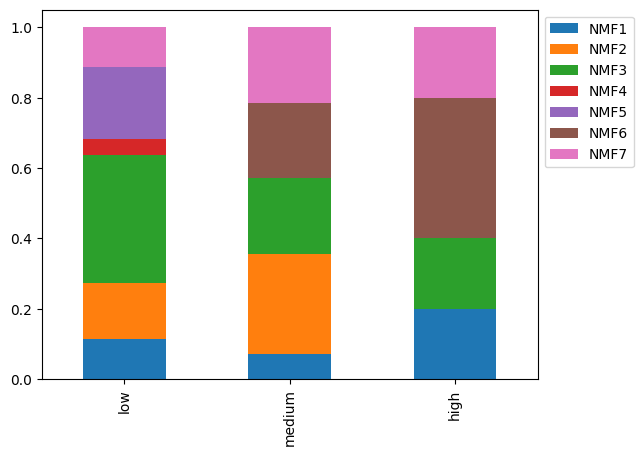

In [47]:
axes = df_nmf_by_resp.transpose().plot(kind='bar', stacked=True)
axes.legend(bbox_to_anchor= (1, 1)) 

In [8]:
nmf_grp5 = np.array([])
for i in range(datah5.shape[1]):
    nmf_grp5 = np.append(nmf_grp5, np.argmax(datah5[:,i]))
nmf_grp5

array([4., 4., 0., 4., 0., 4., 4., 4., 1., 1., 0., 2., 2., 4., 4., 4., 1.,
       1., 4., 2., 4., 3., 4., 0., 2., 4., 2., 4., 4., 4., 3., 4., 4., 3.,
       4., 4., 1., 4., 0., 4., 4., 1., 1., 4., 4., 4., 3., 1., 1., 1., 1.,
       1., 1., 0., 0., 4., 1., 1., 3., 1., 4.])

In [53]:
symbols_name = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']
df_nmf_by_resp = pd.DataFrame(columns=['low', 'medium', 'high'], index=symbols_name)
resp_level_order = [0,1,2]
nmf_typ_order = [0,1,2,3,4]
for x in range(3):
    resp=resp_level_order[x]
    print(np.sum(k_model.labels_==resp))
    for y in nmf_typ_order:
        #print(y)
        df_nmf_by_resp.iloc[y,x] = np.sum(nmf_grp5.astype(int)[k_model.labels_==resp]==y)

df_nmf_by_resp

48
10
3


,low,medium,high
NMF1,7,0,0
NMF2,11,3,2
NMF3,3,2,0
NMF4,2,2,1
NMF5,25,3,0


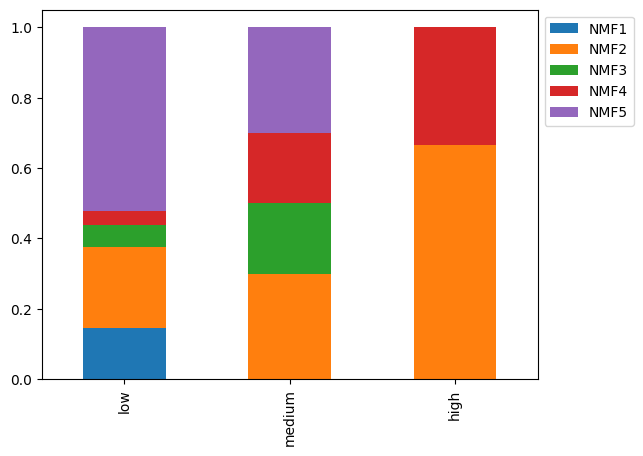

In [54]:
df_nmf_by_resp = df_nmf_by_resp/df_nmf_by_resp.sum()
axes = df_nmf_by_resp.transpose().plot(kind='bar', stacked=True)
axes.legend(bbox_to_anchor= (1, 1)) 

In [ ]:
fig = plt.figure(num=None, figsize=(12, 8) ) 
m = Basemap(width=6000000,height=4500000,resolution='c',projection='aea',lon_0=-100,lat_0=40)
m.drawcoastlines()
m.fillcontinents()
m.drawcountries(linewidth=2, linestyle='solid', color='k' ) 
m.drawstates(linewidth=0.5, linestyle='solid', color='k')
m.drawmapboundary()
color_list = ['green', 'red', 'blue']
color_names = ['medium', 'high', 'low']
colors = [color_list[i] for i in k_model.labels_]
#colors = [plt.cm.tab10(i) for i in k_model.labels_] # using the "tab10" colormap
symbols_list = ['o', 's', '^', 'v', 'D']
symbols_name = ['NMF1', 'NMF2', 'NMF3', 'NMF4', 'NMF5']
symbols = [symbols_list[int(i)] for i in nmf_grp5]
#handles = [matplotlib.patches.Patch(color=plt.cm.tab10(i), label=c) for i, c in enumerate(top_cats)]


x, y = m(df_env_btm['Long'], df_env_btm['Lat'])
data = np.column_stack((x, y, colors))
for ci in ['blue', 'green', 'red']:
    mask = [c==ci for c in colors]
    xi, yi, symbi = x[mask], y[mask], np.array(symbols)[mask]
    for i in range(len(xi)):
        plt.scatter(xi[i], yi[i], marker=symbi[i], c=ci)

legend_markers = [plt.Line2D([0], [0], linestyle='none', marker=symbols_list[i], color='black') for i in range(len(symbols_list))]
legend_colors = [plt.Rectangle((0, 0), 1, 1, fc=color_list[i]) for i in range(len(color_list))]

plt.legend(legend_markers + legend_colors, symbols_name + color_names)
plt.title("Bottom Soil Respiration and DOM types")
plt.show()

In [12]:
plt.cm.tab10(2.)

(0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0)

In [5]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [6]:
results_loc = '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt/5/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah5 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah5.shape)

(5, 16)
(5, 15)
(5, 15)
(5, 15)
(5, 61)


gridsearch CV

data augmentation
mixup, add noise to training only https://arxiv.org/pdf/1710.09412.pdf



findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


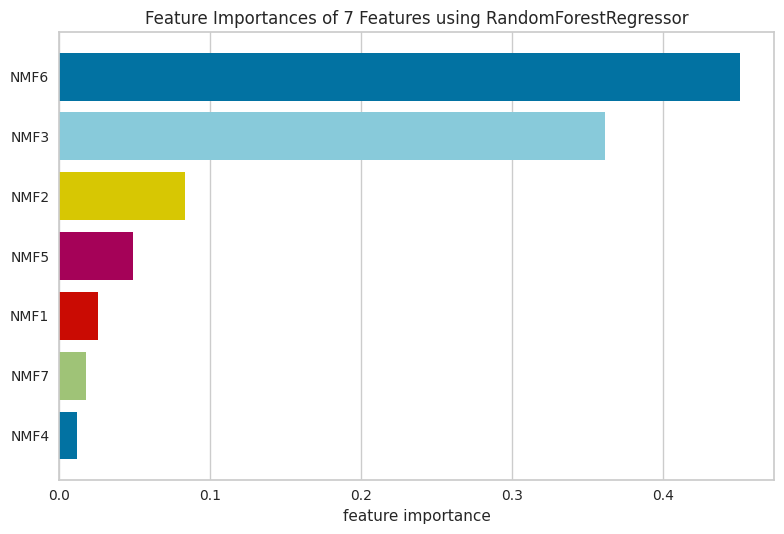

<AxesSubplot:title={'center':'Feature Importances of 7 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [7]:
from sklearn.ensemble import RandomForestRegressor
from yellowbrick.model_selection import FeatureImportances

X, y = datah7.T, df_env_top['Respiratio'].iloc[:,1].values
viz = FeatureImportances(RandomForestRegressor(), labels=['NMF1','NMF2','NMF3','NMF4','NMF5','NMF6','NMF7'], relative=False)

# Fit and show the feature importancesQ
viz.fit(X, y)
viz.show()

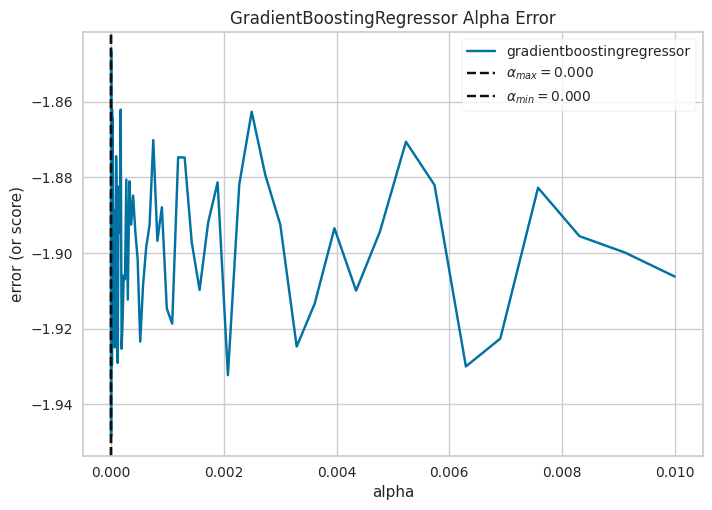

<AxesSubplot:title={'center':'GradientBoostingRegressor Alpha Error'}, xlabel='alpha', ylabel='error (or score)'>

In [19]:
#from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from yellowbrick.regressor import ManualAlphaSelection

X, y = np.log(datah7.T+1), np.log(df_env_top['Respiratio'].iloc[:,1].values+1)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)
alphas = np.logspace(-4, -2, 50)

# Instantiate the visualizer
visualizer = ManualAlphaSelection(
    GradientBoostingRegressor(),
    ccp_alpha = alphas,
    cv=5,
    logx=True,
    scoring="neg_mean_squared_error"
)

visualizer.fit(X, y)
visualizer.show()


#parameters = {'max_depth':np.arange(10,50,2), 'ccp_alpha':np.logspace(-5, 3,100)}
#clf = GridSearchCV(RandomForestRegressor(), parameters, return_train_score=True)
#clf.fit(X_train, y_train)

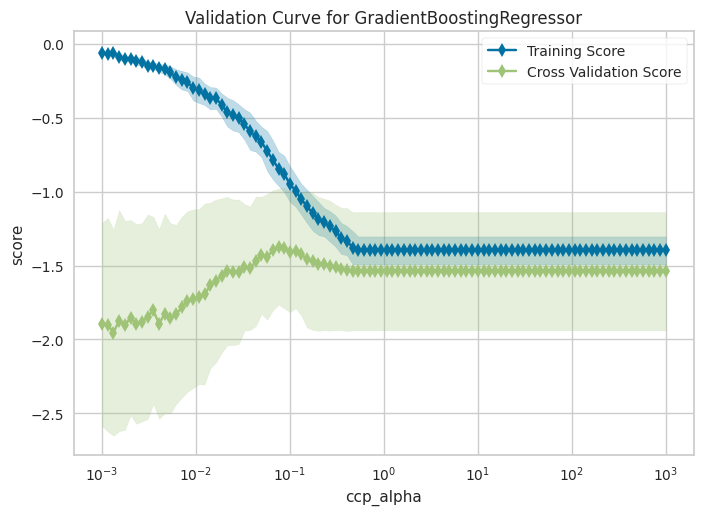

<AxesSubplot:title={'center':'Validation Curve for GradientBoostingRegressor'}, xlabel='ccp_alpha', ylabel='score'>

In [20]:
from yellowbrick.model_selection import ValidationCurve
viz = ValidationCurve(
    GradientBoostingRegressor(), param_name="ccp_alpha",
    param_range=np.logspace(-3, 3,100), cv=5, logx=True,scoring="neg_mean_squared_error"
)

# Fit and show the visualizer
viz.fit(X, y)
viz.show()

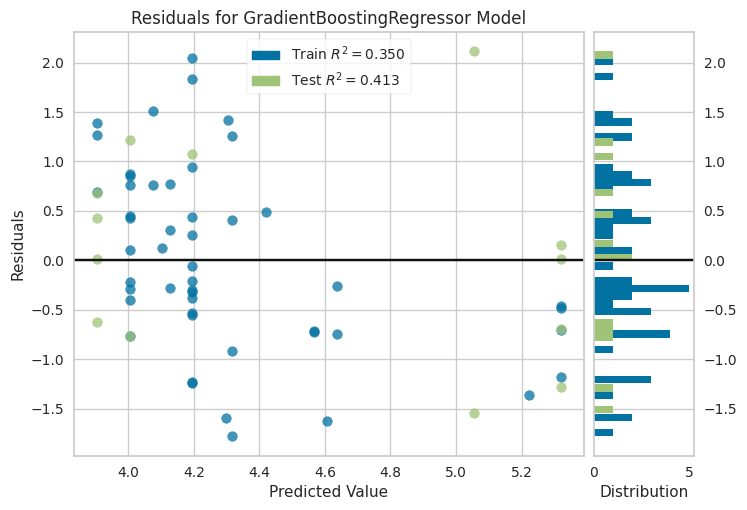

In [26]:
from yellowbrick.regressor import residuals_plot
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30)

viz = residuals_plot(GradientBoostingRegressor(ccp_alpha=0.05), X_train, y_train, X_test, y_test)

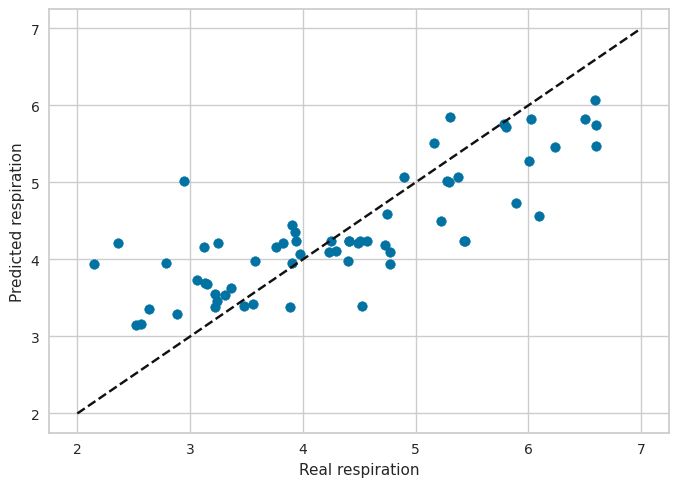

In [32]:
from matplotlib import pyplot as plt
import forestci as fci

resp_forest = GradientBoostingRegressor(ccp_alpha=0.01)
resp_forest.fit(X_train, y_train)
y_hat = resp_forest.predict(X_test)

# Plot predicted MPG without error bars
plt.scatter(y, resp_forest.predict(X))
plt.plot([2, 7], [2, 7], 'k--')
plt.xlabel('Real respiration')
plt.ylabel('Predicted respiration')
plt.show()

# Calculate the variance
#unbiased = fci.random_forest_error(resp_forest, X_train,X_test)

# Plot error bars for predicted MPG using unbiased variance
#plt.errorbar(y_test, y_hat, yerr=np.sqrt(unbiased), fmt='o')
#plt.plot([5, 45], [5, 45], 'k--')
#plt.xlabel('Real respiration')
#plt.ylabel('Predicted respiration')
#plt.show()

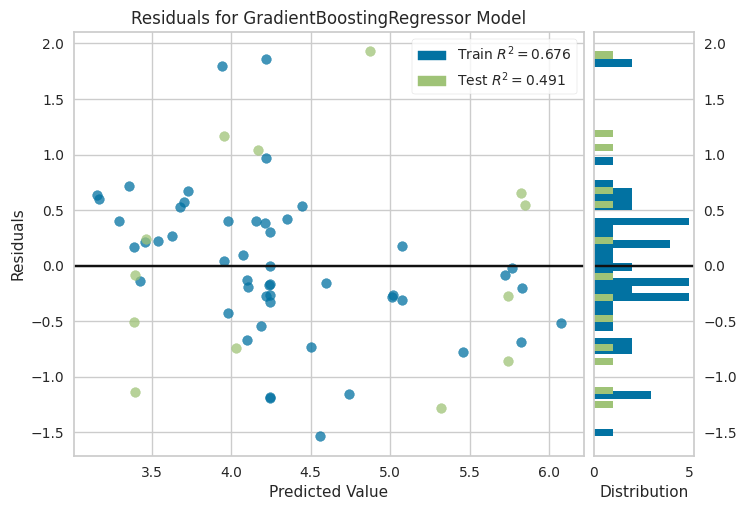

In [35]:
viz = residuals_plot(GradientBoostingRegressor(ccp_alpha=0.01), X_train, y_train, X_test, y_test)

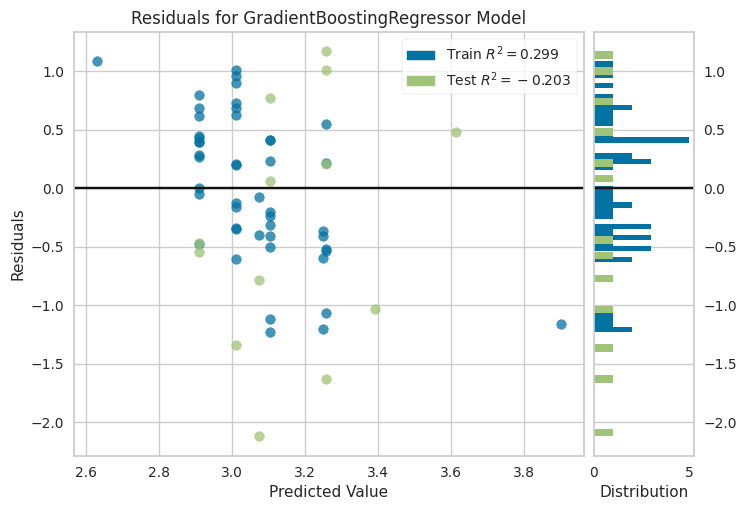

In [37]:
from yellowbrick.regressor import residuals_plot
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

X, y = np.log(datah5.T+1), np.log(df_env_btm['Respiratio'].iloc[:,1].values+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

viz = residuals_plot(GradientBoostingRegressor(ccp_alpha=0.03), X_train, y_train, X_test, y_test)

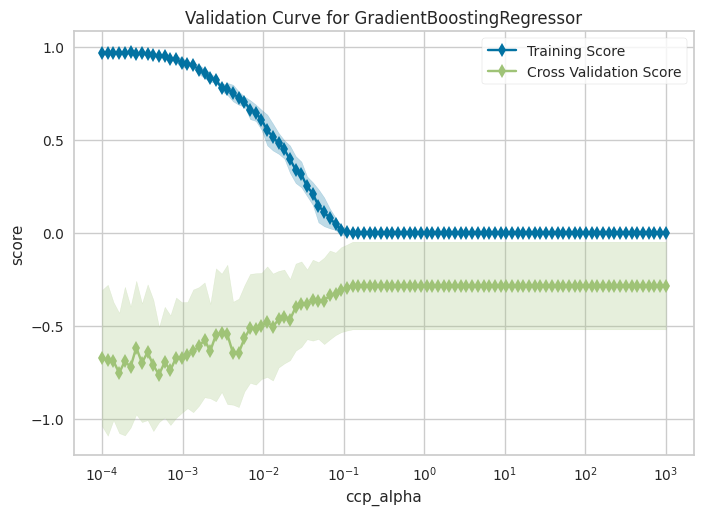

<AxesSubplot:title={'center':'Validation Curve for GradientBoostingRegressor'}, xlabel='ccp_alpha', ylabel='score'>

In [28]:
from yellowbrick.model_selection import ValidationCurve
viz = ValidationCurve(
    GradientBoostingRegressor(), param_name="ccp_alpha",
    param_range=np.logspace(-4, 3,100), cv=5, logx=True,scoring="r2"
)

# Fit and show the visualizer
viz.fit(X, y)
viz.show()

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.kernel_ridge import KernelRidge

svr = GridSearchCV(
    SVR(kernel="rbf", gamma=0.1),
    param_grid={"C": [1e0, 1e1, 1e2, 1e3], "gamma": np.logspace(-2, 2, 5)},
)

kr = GridSearchCV(
    KernelRidge(kernel="rbf", gamma=0.1),
    param_grid={"alpha": [1e0, 0.1, 1e-2, 1e-3], "gamma": np.logspace(-2, 2, 5)},
)

In [59]:
svr.best_estimator_.score(X_test,y_test)

0.7364841789859161

In [83]:
print(svr.best_params_)
print(kr.best_params_)

{'C': 1.0, 'gamma': 1.0}
{'alpha': 1.0, 'gamma': 0.01}


In [50]:
y_svr = svr.predict(X_test)
y_kr = svr.predict(X_test)


Text(0, 0.5, 'predicted')

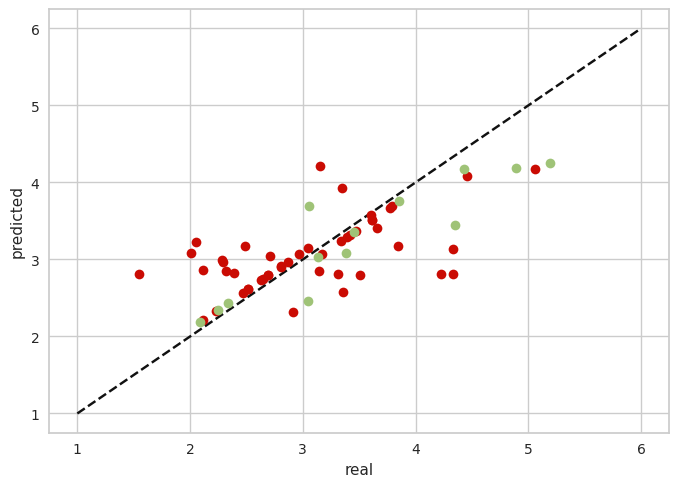

In [57]:

#plt.scatter(X[:100], y[:100], c="k", label="data", zorder=1, edgecolors=(0, 0, 0))
plt.plot([1, 6], [1, 6], 'k--')
plt.plot(
    y_train,
    svr.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    svr.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

Text(0, 0.5, 'predicted')

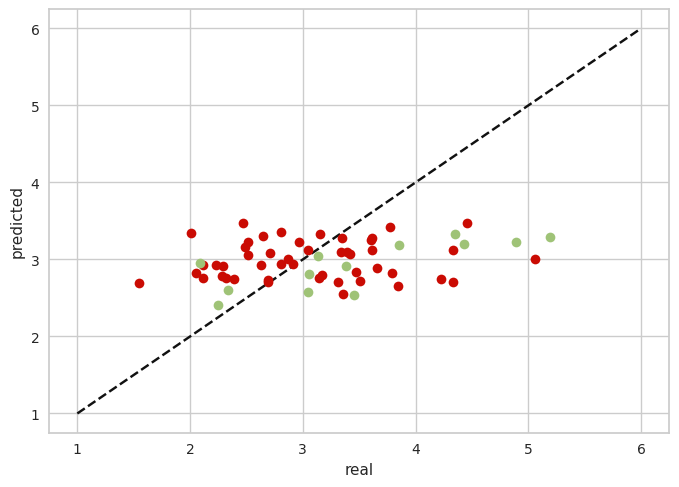

In [62]:
plt.plot([1, 6], [1, 6], 'k--')
plt.plot(
    y_train,
    kr.predict(X_train),
    c="r",
    marker='o', linewidth=0
)
plt.plot(y_test,    kr.predict(X_test),    c="g",    marker='o', linewidth=0)
plt.xlabel("real")
plt.ylabel("predicted")

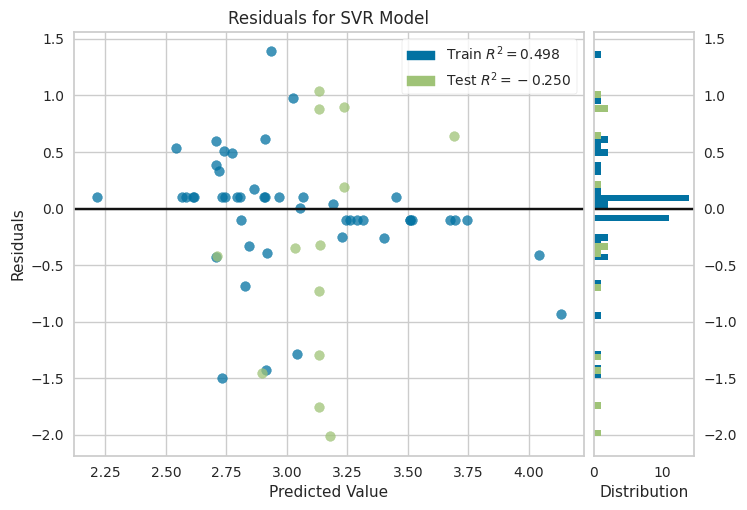

In [80]:
viz = residuals_plot(SVR(kernel="rbf", gamma=1.0, C=1.0), X_train, y_train, X_test, y_test)

In [90]:
svr_test = SVR(kernel="rbf", gamma=2.0, C=1.0)
svr_test.fit(X_train, y_train)
print(svr_test.score(X_train,y_train))
print(svr_test.score(X_test,y_test))

0.528702820320463
-0.3348867789032204


In [31]:
X, y = df_env_top_pred, np.log(df_env_top['Respiratio'].iloc[:,1].values)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

parameters = {'max_depth':np.arange(10,50,2), 'ccp_alpha':np.logspace(-5, 3,100)}
clf = GridSearchCV(RandomForestRegressor(), parameters, return_train_score=True)
clf.fit(X_train, y_train)
print(clf.best_score_)
print(clf.best_estimator_.score(X_train,y_train))

0.2378376576134456
0.8763677585956771


In [32]:
clf.best_estimator_

RandomForestRegressor(ccp_alpha=0.024770763559917114, max_depth=18)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif


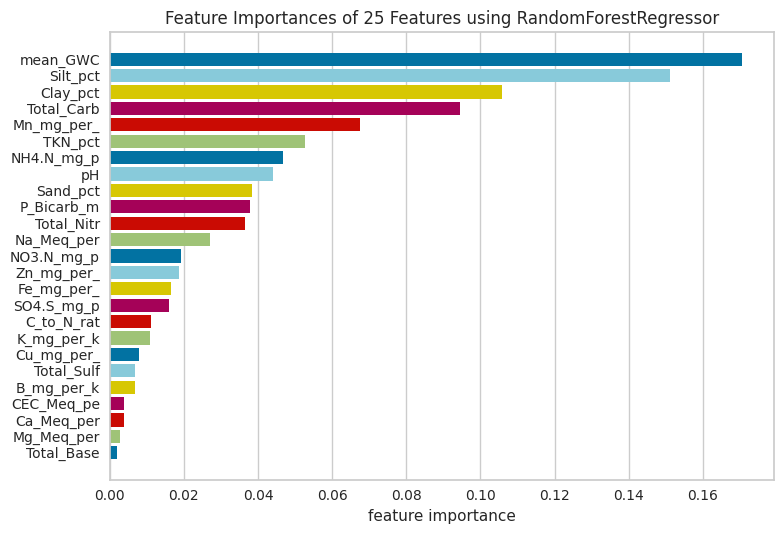

<AxesSubplot:title={'center':'Feature Importances of 25 Features using RandomForestRegressor'}, xlabel='feature importance'>

In [33]:
from yellowbrick.model_selection import FeatureImportances

viz = FeatureImportances(RandomForestRegressor(ccp_alpha=0.024770763559917114, max_depth=18), labels=df_env_top_pred.columns, relative=False)

# Fit and show the feature importancesQ
viz.fit(X, y)
viz.show()

In [35]:
def mixup_data(x1, x2, y1, y2):

    lam   = 0.5 #Sample from beta distribution
    x_lam = lam * x1 + (1.0 - lam) * x2 #Mixup inputs vectors
    y_lam = lam * y1 + (1.0 - lam) * y2 #Mixup output vectors

    return x_lam, y_lam

X_mix = [[None] * 7]
y_mix = []
for i in np.arange(len(y_train)):
    for j in np.arange(i+1,len(y_train)):
        x_new, y_new = mixup_data(X_train[i,:], X_train[j,:], y_train[i], y_train[j])
        X_mix = np.append(X_mix, [x_new], axis=0)
        y_mix = np.append(y_mix, y_new)
    print(i)
    print(X_mix.shape)
    print(y_mix.shape)


0
(44, 7)
(43,)
1
(86, 7)
(85,)
2
(127, 7)
(126,)
3
(167, 7)
(166,)
4
(206, 7)
(205,)
5
(244, 7)
(243,)
6
(281, 7)
(280,)
7
(317, 7)
(316,)
8
(352, 7)
(351,)
9
(386, 7)
(385,)
10
(419, 7)
(418,)
11
(451, 7)
(450,)
12
(482, 7)
(481,)
13
(512, 7)
(511,)
14
(541, 7)
(540,)
15
(569, 7)
(568,)
16
(596, 7)
(595,)
17
(622, 7)
(621,)
18
(647, 7)
(646,)
19
(671, 7)
(670,)
20
(694, 7)
(693,)
21
(716, 7)
(715,)
22
(737, 7)
(736,)
23
(757, 7)
(756,)
24
(776, 7)
(775,)
25
(794, 7)
(793,)
26
(811, 7)
(810,)
27
(827, 7)
(826,)
28
(842, 7)
(841,)
29
(856, 7)
(855,)
30
(869, 7)
(868,)
31
(881, 7)
(880,)
32
(892, 7)
(891,)
33
(902, 7)
(901,)
34
(911, 7)
(910,)
35
(919, 7)
(918,)
36
(926, 7)
(925,)
37
(932, 7)
(931,)
38
(937, 7)
(936,)
39
(941, 7)
(940,)
40
(944, 7)
(943,)
41
(946, 7)
(945,)
42
(947, 7)
(946,)
43
(947, 7)
(946,)


In [38]:
parameters = {'max_depth':np.arange(10,50,2), 'ccp_alpha':np.logspace(-5, 3,100)}
clf = GridSearchCV(RandomForestRegressor(), parameters, return_train_score=True)
clf.fit(X_mix[1:,:], y_mix)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'ccp_alpha': array([1.00000000e-05, 1.20450354e-05, 1.45082878e-05, 1.74752840e-05,
       2.10490414e-05, 2.53536449e-05, 3.05385551e-05, 3.67837977e-05,
       4.43062146e-05, 5.33669923e-05, 6.42807312e-05, 7.74263683e-05,
       9.32603347e-05, 1.12332403e-04, 1.35304777e-04, 1.62975083e-04,
       1.96304065e-04, 2.36448941e-04, 2....
       2.91505306e+01, 3.51119173e+01, 4.22924287e+01, 5.09413801e+01,
       6.13590727e+01, 7.39072203e+01, 8.90215085e+01, 1.07226722e+02,
       1.29154967e+02, 1.55567614e+02, 1.87381742e+02, 2.25701972e+02,
       2.71858824e+02, 3.27454916e+02, 3.94420606e+02, 4.75081016e+02,
       5.72236766e+02, 6.89261210e+02, 8.30217568e+02, 1.00000000e+03]),
                         'max_depth': array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42,
       44, 46, 48])},
             return_train_score=True)

In [39]:
clf.cv_results_['mean_test_score'].max()

0.670147804241085

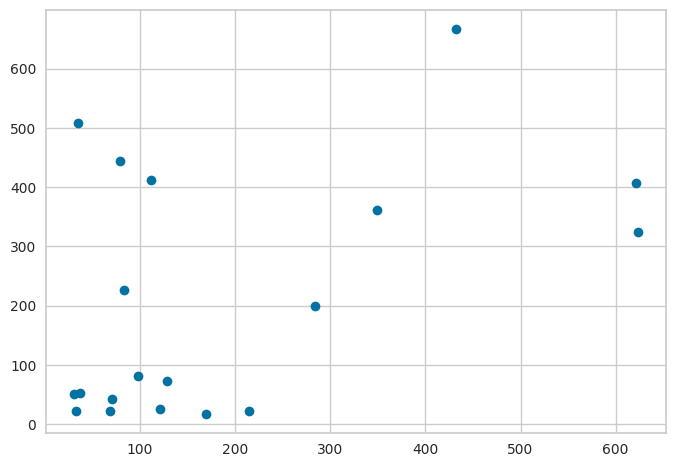

In [40]:
plt.plot(clf.predict(X_test), y_test, marker='o', linewidth=0)

In [42]:
clf.best_estimator_.score(X_test, y_test)

0.022743320221092378

In [1]:
import joblib
clf = joblib.load('/home/shic892/corems/RF_NMF_log_nolignin_4149_top_respiration_log.pkl')

In [14]:
import pandas as pd
import numpy as np
df_sites_qc = pd.read_csv('/home/shic892/corems/1000_soils_124x7880_122122.csv', index_col=0)
site_depth = [x[5:8] for x in df_sites_qc.index.values]
df_sites_qc_top = df_sites_qc.iloc[[x=='TOP' for x in site_depth],:]
df_sites_qc_top = df_sites_qc_top.loc[:,df_sites_qc_top.sum()>0]
df_env = pd.read_csv('/home/shic892/corems/1000s_env_w_biome_more.csv', index_col = 0,encoding='latin-1')
df_env.columns = [x[0:10] for x in df_env.columns]
df_env_top = df_env.loc[df_sites_qc_top.index.values,:]

results_loc = '/home/shic892/pyDNMFk/Results/1000s_top_no_lignin_4149x63_nt/7/'
# '/home/shic892/pyDNMFk/Results/1000s_btm_5515x61_nt'
# '/home/shic892/pyDNMFk/Results/1000s_top_7312x63_nt
datah0 = np.load(results_loc+'H_reg_factors/H_0.npy')
print(datah0.shape)
datah1 = np.load(results_loc+'H_reg_factors/H_1.npy')
print(datah1.shape)
datah2 = np.load(results_loc+'H_reg_factors/H_2.npy')
print(datah2.shape)
datah3 = np.load(results_loc+'H_reg_factors/H_3.npy')
print(datah3.shape)
datah7 = np.concatenate((datah0,datah1,datah2,datah3), axis=1)
#np.savetxt('1000s_nmf_9_H_124.csv', data, delimiter=',')
print(datah7.shape)

from sklearn.model_selection import train_test_split
X, y = np.log(datah7.T+1), np.log(df_env_top['Respiratio'].iloc[:,1].values)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

(7, 16)
(7, 16)
(7, 16)
(7, 15)
(7, 63)


In [8]:
clf.score(X_test, y_test)

0.01829644525412366

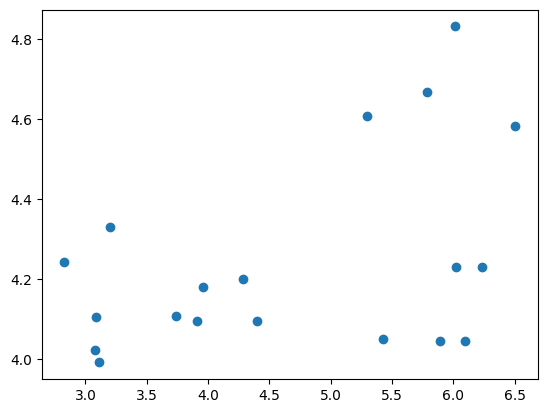

In [7]:
import matplotlib.pyplot as plt
plt.plot(y_test, clf.predict(X_test),marker='o', linewidth=0)

In [9]:
clf = joblib.load('/home/shic892/corems/RF_NMF_nolignin_log_top_respiration_log_test.pkl')

In [15]:
clf.score(X_test, y_test)

-0.17411759544887406

In [16]:
clf.best_params_

{'ccp_alpha': 1.7782794100389228,
 'max_depth': 30,
 'max_features': 'log2',
 'min_samples_split': 4,
 'n_estimators': 302}

In [12]:
df_env_top_pred = df_env_top.iloc[:,np.append(range(0,22), range(25,28))]
df_env_top_pred = df_env_top_pred.fillna(df_env_top_pred.mean())

X = np.log(df_env_top_pred+1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)